C:\Users\Admin\AppData\Local\Temp\ipykernel_3684\928310362.py:3: DeprecationWarning: `scipy.odr` is deprecated as of version 1.17.0 and will be removed in SciPy 1.19.0. Please use `https://pypi.org/project/odrpack/` instead.
  from scipy.odr import polynomial


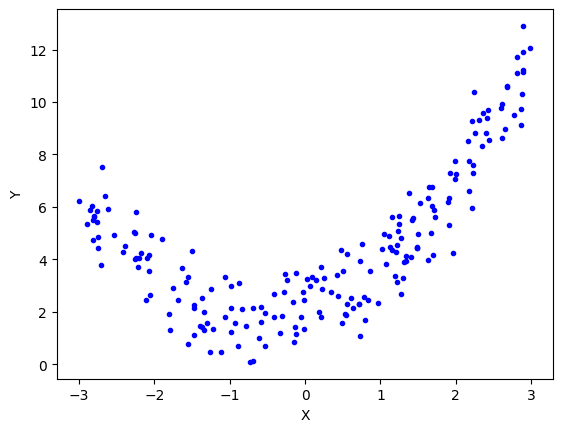

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.odr import polynomial
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

#generating random quadratic data with noise
X = 6 * np.random.rand(200,1) - 3
Y = 0.8 * X**2 + 0.9*X +2 +np.random.randn(200,1)
#plotting initial dataset distribution
plt.plot(X,Y,'b.')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [2]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=40)

#linear regression model
lr = LinearRegression()
lr.fit(X_train,Y_train)
y_pred = lr.predict(X_test)
print("R2 score for Linear Regression",r2_score(Y_test,y_pred))

R2 score for Linear Regression 0.33242285737284627


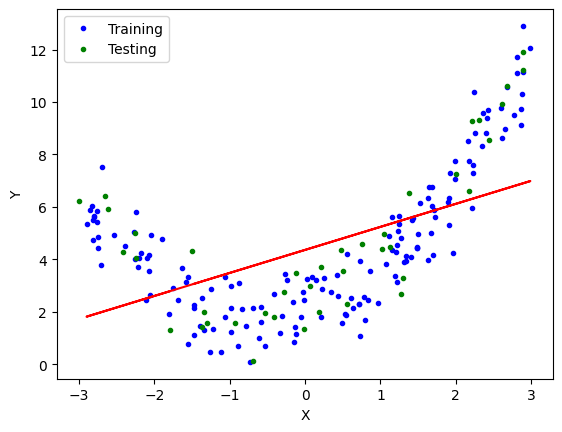

In [3]:
#visulaizing linear model fit

##################################################uuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuu
plt.plot(X_train,Y_train,'b.',label = 'Training')
plt.plot(X_test,Y_test,'g.',label = 'Testing')
plt.plot(X_train,lr.predict(X_train),color = 'red')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

In [4]:
#now apply polynomial feature engineering degree=2
poly=PolynomialFeatures(degree=2,include_bias=True)###b0
X_train_trans=poly.fit_transform(X_train)
X_test_trans=poly.fit_transform(X_test)

In [5]:
#fitting polynomial regression model

plr = LinearRegression()
plr.fit(X_train_trans,Y_train)
y_pred = plr.predict(X_test_trans)
##y_pred=ndarray.flatten()

#display performance and learned model parameters
print("R2 score for polynomial Regression",r2_score(Y_test,y_pred))
print("coefficients b1,b2=",plr.coef_)
print("b0=",plr.intercept_)

R2 score for polynomial Regression 0.8826071875082663
coefficients b1,b2= [[0.         0.88581174 0.78188563]]
b0= [1.98907936]


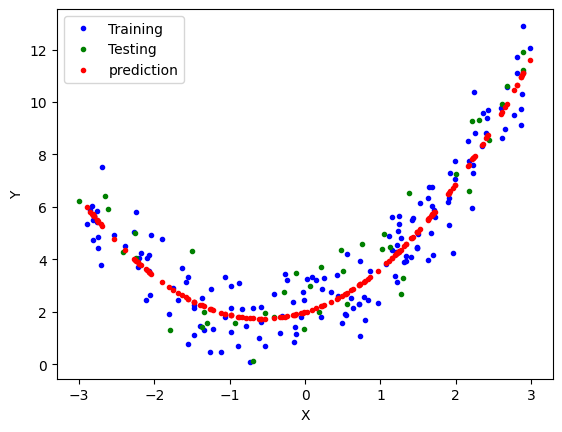

In [6]:
#now visulaizing polynomial model fit

yp=plr.predict(X_train_trans)
yp=np.ndarray.flatten(yp)

#now we have to plot final polynomial predictions alongside actual partitions
plt.plot(X_train,Y_train,'b.',label = 'Training')
plt.plot(X_test,Y_test,'g.',label = 'Testing')
plt.plot(X_train,yp, 'r.',label='prediction')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()